<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Quantum_Informed_Cu_Adhesion_on_SiO2_TiO2_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

## Quantum-Informed Cu Adhesion on SiO2 and TiO2

This notebook expands the supplied interfacial-adhesion concept into a defensible reduced model for copper adhesion on silicon dioxide and titanium dioxide. The central physical idea is that adhesion at a scaled metal/oxide interface is governed by local electronic structure, since bonding depends on orbital hybridization, charge transfer, defect-mediated states, surface termination, and adsorbate chemistry at length scales where a macroscopic enthalpy chart becomes too coarse.

The composite Ehrenfest, Landau-Lifshitz-Bloch, and Boltzmann language is useful as a multiscale scaffold. It should be presented as a reduced modeling ansatz whose pieces describe separate physics. Ehrenfest dynamics gives expectation-value motion under a Hamiltonian, Landau-Lifshitz-Bloch dynamics gives finite-temperature spin relaxation, and Boltzmann transport gives nonequilibrium carrier redistribution. A single canonical equation with the full combined name is unavailable in standard usage, so the notebook builds a transparent surrogate that connects those ingredients without overclaiming exact first-principles predictive power.

QuTiP helps when the goal is explicit density-matrix time evolution with Hamiltonians and relaxation channels. CuPy helps when the goal is a large heat-map sweep across thousands of interfacial parameter points. The code therefore uses CuPy when a CUDA GPU is available, while QuTiP is used opportunistically for a representative open-system spin trace and a SciPy fallback is included for robustness.

### Terminology used in the model

| Symbol | Meaning | Physical role |
| --- | --- | --- |
| $W_{ad}$ | Adhesion work or adhesion proxy | Interfacial energy scale associated with separating Cu from the oxide |
| $\xi$ | Defect-mediated electron-rich site fraction | A dimensionless measure of reducible surface sites, such as Ti$^{3+}$-like centers near oxygen vacancies |
| $t_{dp}$ | Cu $d$ to oxide $p/d$ hopping amplitude | The local orbital-overlap parameter that controls covalent or quasi-covalent hybridization |
| $\Delta$ | Cu/oxide level mismatch | The energy detuning between a Cu frontier level and an oxide-derived interfacial state |
| $E_{hyb}$ | Hybridization stabilization | The bonding energy gained when Cu and oxide orbitals mix |
| $q_{ct}$ | Charge-transfer descriptor | A bounded proxy for interfacial electron redistribution |
| $J_{ex}$ | Exchange coupling | A spin-sensitive coupling term relevant when a nearby magnetic layer or spin-polarized carrier reservoir is present |
| $\Gamma$ | Relaxation rate | A phenomenological decay rate for interfacial spin or charge polarization |

The parameter $\xi$ is intentionally broader than an oxygen-vacancy concentration. In reduced TiO2 it can be interpreted as a vacancy/Ti$^{3+}$-rich interfacial state density, while in SiO2 it is ordinarily small unless the surface contains nonbridging oxygen defects, suboxide states, or processing-induced damage. This distinction matters because oxygen-rich, hydroxyl-free SiO2 can form Cu-O bonds, while hydroxylation and oxygen removal weaken Cu adhesion.

### Source-grounded physical picture

First-principles work on Cu/SiO2 found that adhesion depends strongly on surface stoichiometry. Oxygen-rich interfaces allow substantial rearrangement after Cu deposition, Cu-O bond formation, and Cu-$d$/O-$p$ hybridization, while systematic oxygen removal weakens adhesion and hydroxyl termination reduces adhesion. This makes stoichiometric and surface-preparation details central to any Cu/SiO2 argument.

For TiO2, the surface is more chemically reducible, and oxygen vacancies can create Ti$^{3+}$-like electronic states that promote strong metal-support interaction, Cu dispersion, and stability. Calorimetry on Cu adsorption on rutile TiO2 also reports elevated initial heats when defect densities are higher, which supports the idea that defects and step-like sites can dominate early-stage nucleation and adhesion energetics.

A recent XPS and Auger-parameter study comparing Cu clusters on rutile TiO2(110) and native SiOx also reported charge-transfer signatures on both oxide supports. The practical conclusion is that SiO2 should never be treated as electronically vacant in an absolute sense, although reduced TiO2 usually offers a denser and more labile defect-state manifold for charge transfer.

Useful source anchors used while designing the notebook are listed at the end of this notebook.

### Step 1. Two-level hybridization model

A minimal local interfacial Hamiltonian can be written for one Cu-derived orbital and one oxide-derived interfacial orbital as

$$
\hat{H}_{2}=
\begin{pmatrix}
\epsilon_{Cu} & t_{dp} \\
 t_{dp} & \epsilon_{ox}
\end{pmatrix},
\qquad
\Delta = \epsilon_{Cu}-\epsilon_{ox}.
$$

The bonding eigenvalue is lowered by

$$
E_{hyb}=\sqrt{\left(\frac{\Delta}{2}\right)^2+t_{dp}^{2}}-\frac{|\Delta|}{2},
$$

which shows why adhesion increases when the Cu and oxide levels are closer in energy or when the orbital hopping amplitude grows. Defect-derived oxide states reduce the effective mismatch through

$$
\Delta_{eff}(\xi)=\max\left(\Delta_{min},\Delta_0-\alpha_{def}\xi\right),
$$

where $\alpha_{def}$ represents defect-induced level alignment and $\Delta_{min}$ prevents an unphysical singular strong-coupling limit.

### Step 2. Charge-transfer and adhesion descriptors

A bounded charge-transfer descriptor can be expressed with a logistic activation,

$$
q_{ct}(\xi,t_{dp})=
\frac{1}{1+\exp\left[-\frac{\alpha_{ct}\xi+\beta_{ct}t_{dp}-\theta_{ct}}{w_{ct}}\right]},
$$

which rises when reducible defect states and Cu-oxide hopping jointly improve level alignment. The adhesion proxy used in the heat map is

$$
W_{ad}=N_s e\left[w_hE_{hyb}+w_cE_{ct}q_{ct}+w_dE_{def}\frac{\xi}{\xi+\xi_{sat}}\right],
$$

where $N_s$ is the areal site density and $e$ converts electronvolts per site into joules. This expression is a compact descriptor for trends, since real adhesion requires DFT or calorimetry for quantitative prediction.

### Step 3. Ehrenfest and relaxation scaffold

The spin-sensitive part can be represented by

$$
\hat{H}_{spin}=\frac{\hbar}{2}\boldsymbol{\Omega}(\xi,t_{dp})\cdot\boldsymbol{\sigma},
$$

which gives the Ehrenfest equation

$$
\frac{d\langle\boldsymbol{\sigma}\rangle}{dt}
=\boldsymbol{\Omega}\times \langle\boldsymbol{\sigma}\rangle
-\boldsymbol{\Gamma}\odot\left(\langle\boldsymbol{\sigma}\rangle-oldsymbol{\sigma}_{eq}\right).
$$

The precession term represents Hamiltonian torque, while the relaxation term represents finite-temperature spin and dephasing channels. In a complete atomistic workflow, $\boldsymbol{\Omega}$, $\boldsymbol{\Gamma}$, $t_{dp}$, $\Delta$, and $q_{ct}$ would come from DFT, tight binding, Green functions, molecular dynamics, or experiment. In this notebook they are exposed as control knobs so the heat map can be used as a reasoning tool before a more expensive calculation.

In [ ]:
# Execute once in Google Colab.
!python -m pip -q install uv
!uv pip install --system -q numpy pandas matplotlib scipy qutip cupy-cuda12x

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 99.1 MB/s eta 0:00:00


Array backend: CuPy CUDA
Spin solver: QuTiP Lindblad

Representative interface metrics:
                             case    xi  t_dp_eV  delta_eff_eV  E_hyb_eV_per_site    q_ct  W_ad_proxy_mJ_m2  Omega_x_ps^-1  Gamma_ps^-1
      hydroxylated or native SiO2 0.015     0.20       2.17525            0.01824 0.01266          27.64732        0.02649      0.04601
             dry oxygen-rich SiO2 0.035     0.45       2.14225            0.09069 0.08608         115.53587        0.10994      0.05189
           low-defect rutile TiO2 0.120     0.55       2.00200            0.14115 0.37607         262.39785        0.20715      0.07509
reduced TiO2 with Ti3+-like sites 0.520     0.76       1.34200            0.34282 0.99840         634.93610        0.62882      0.12487


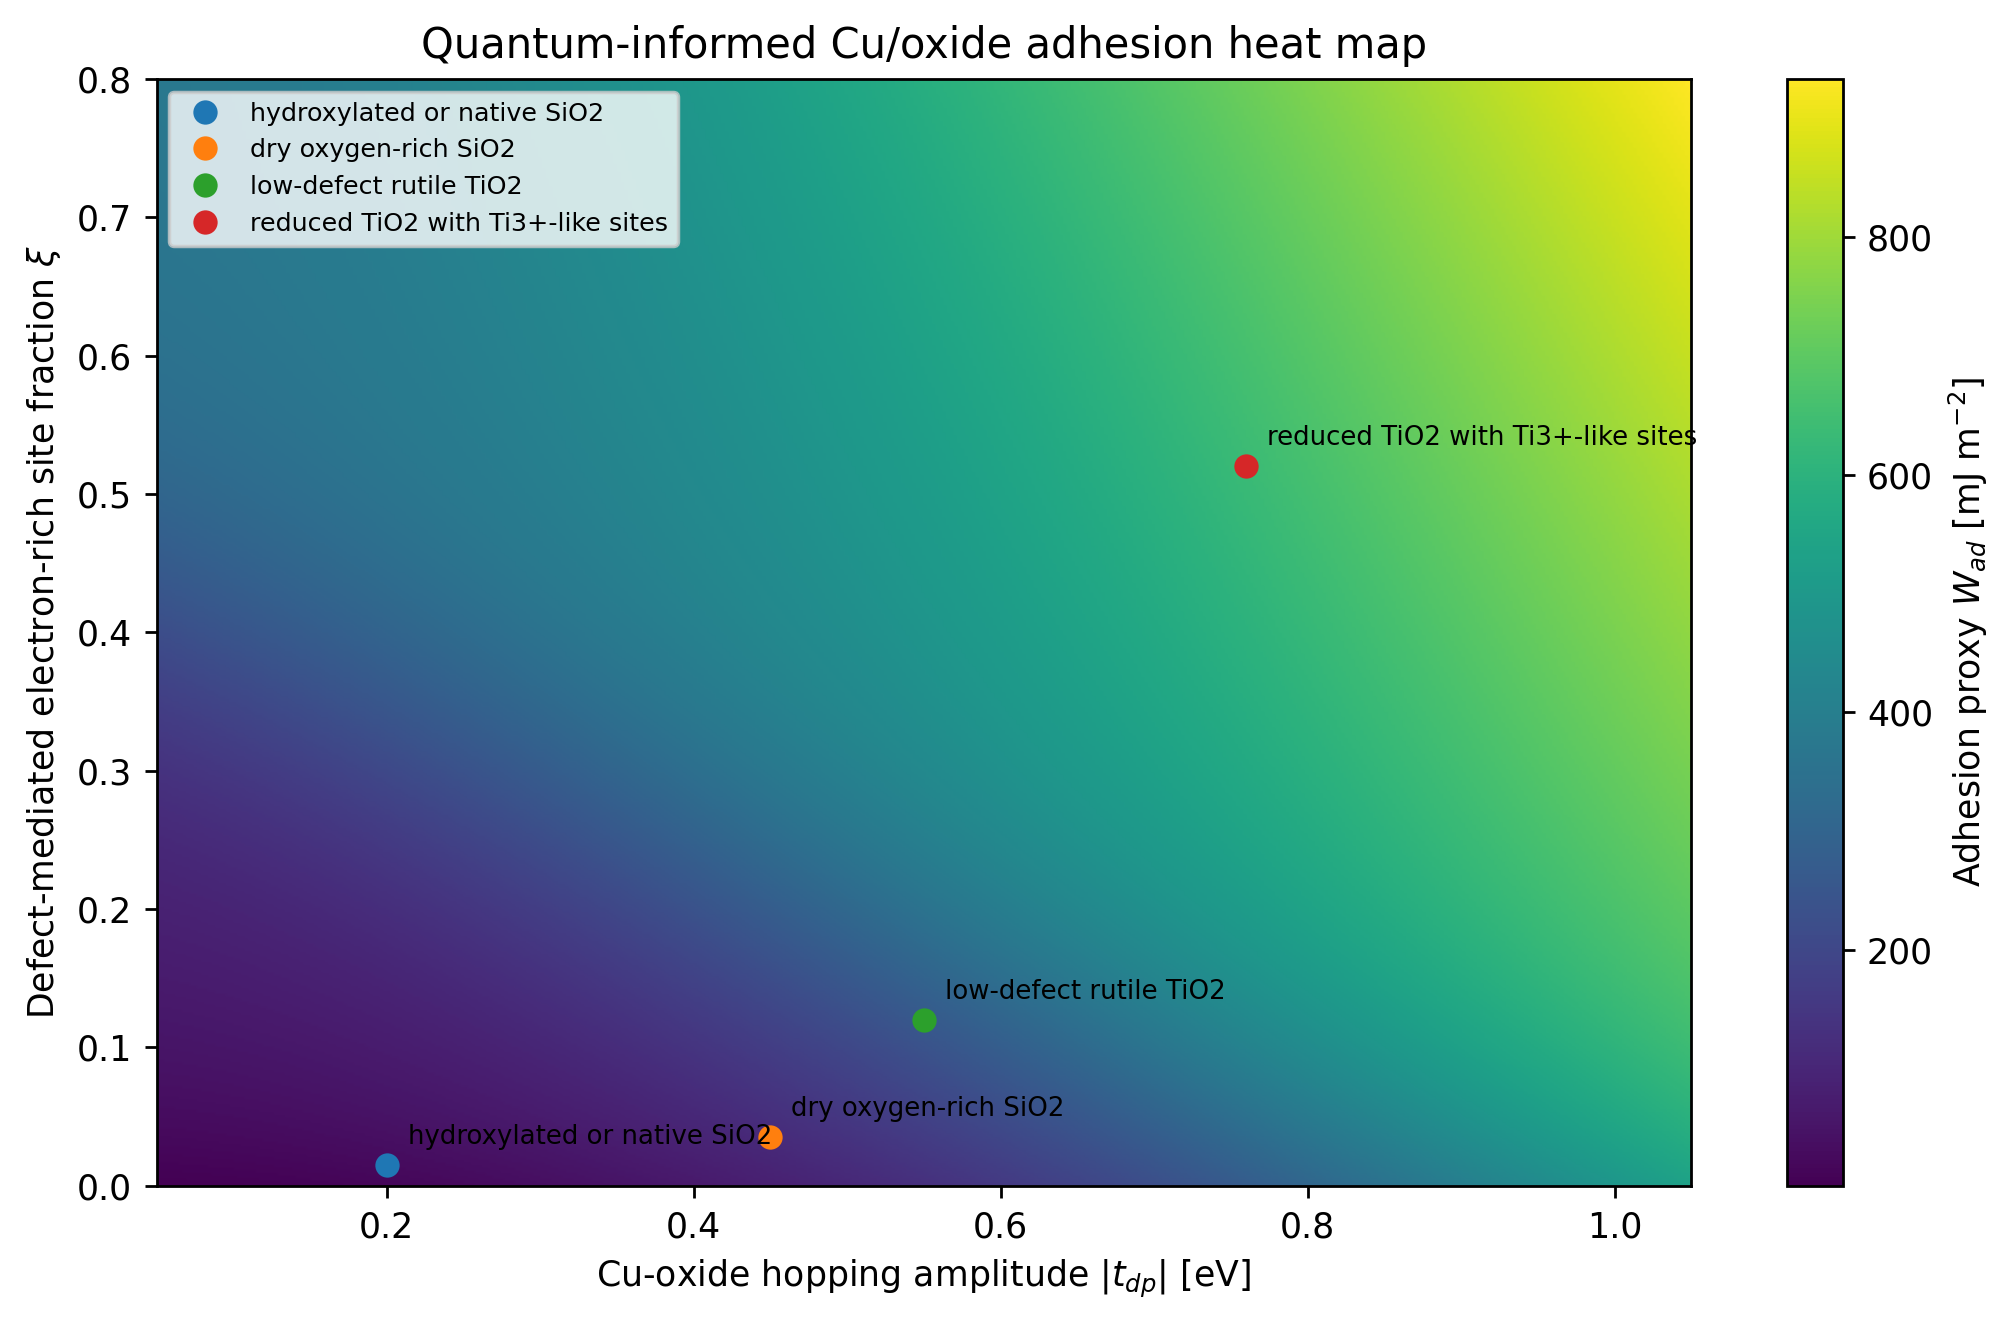

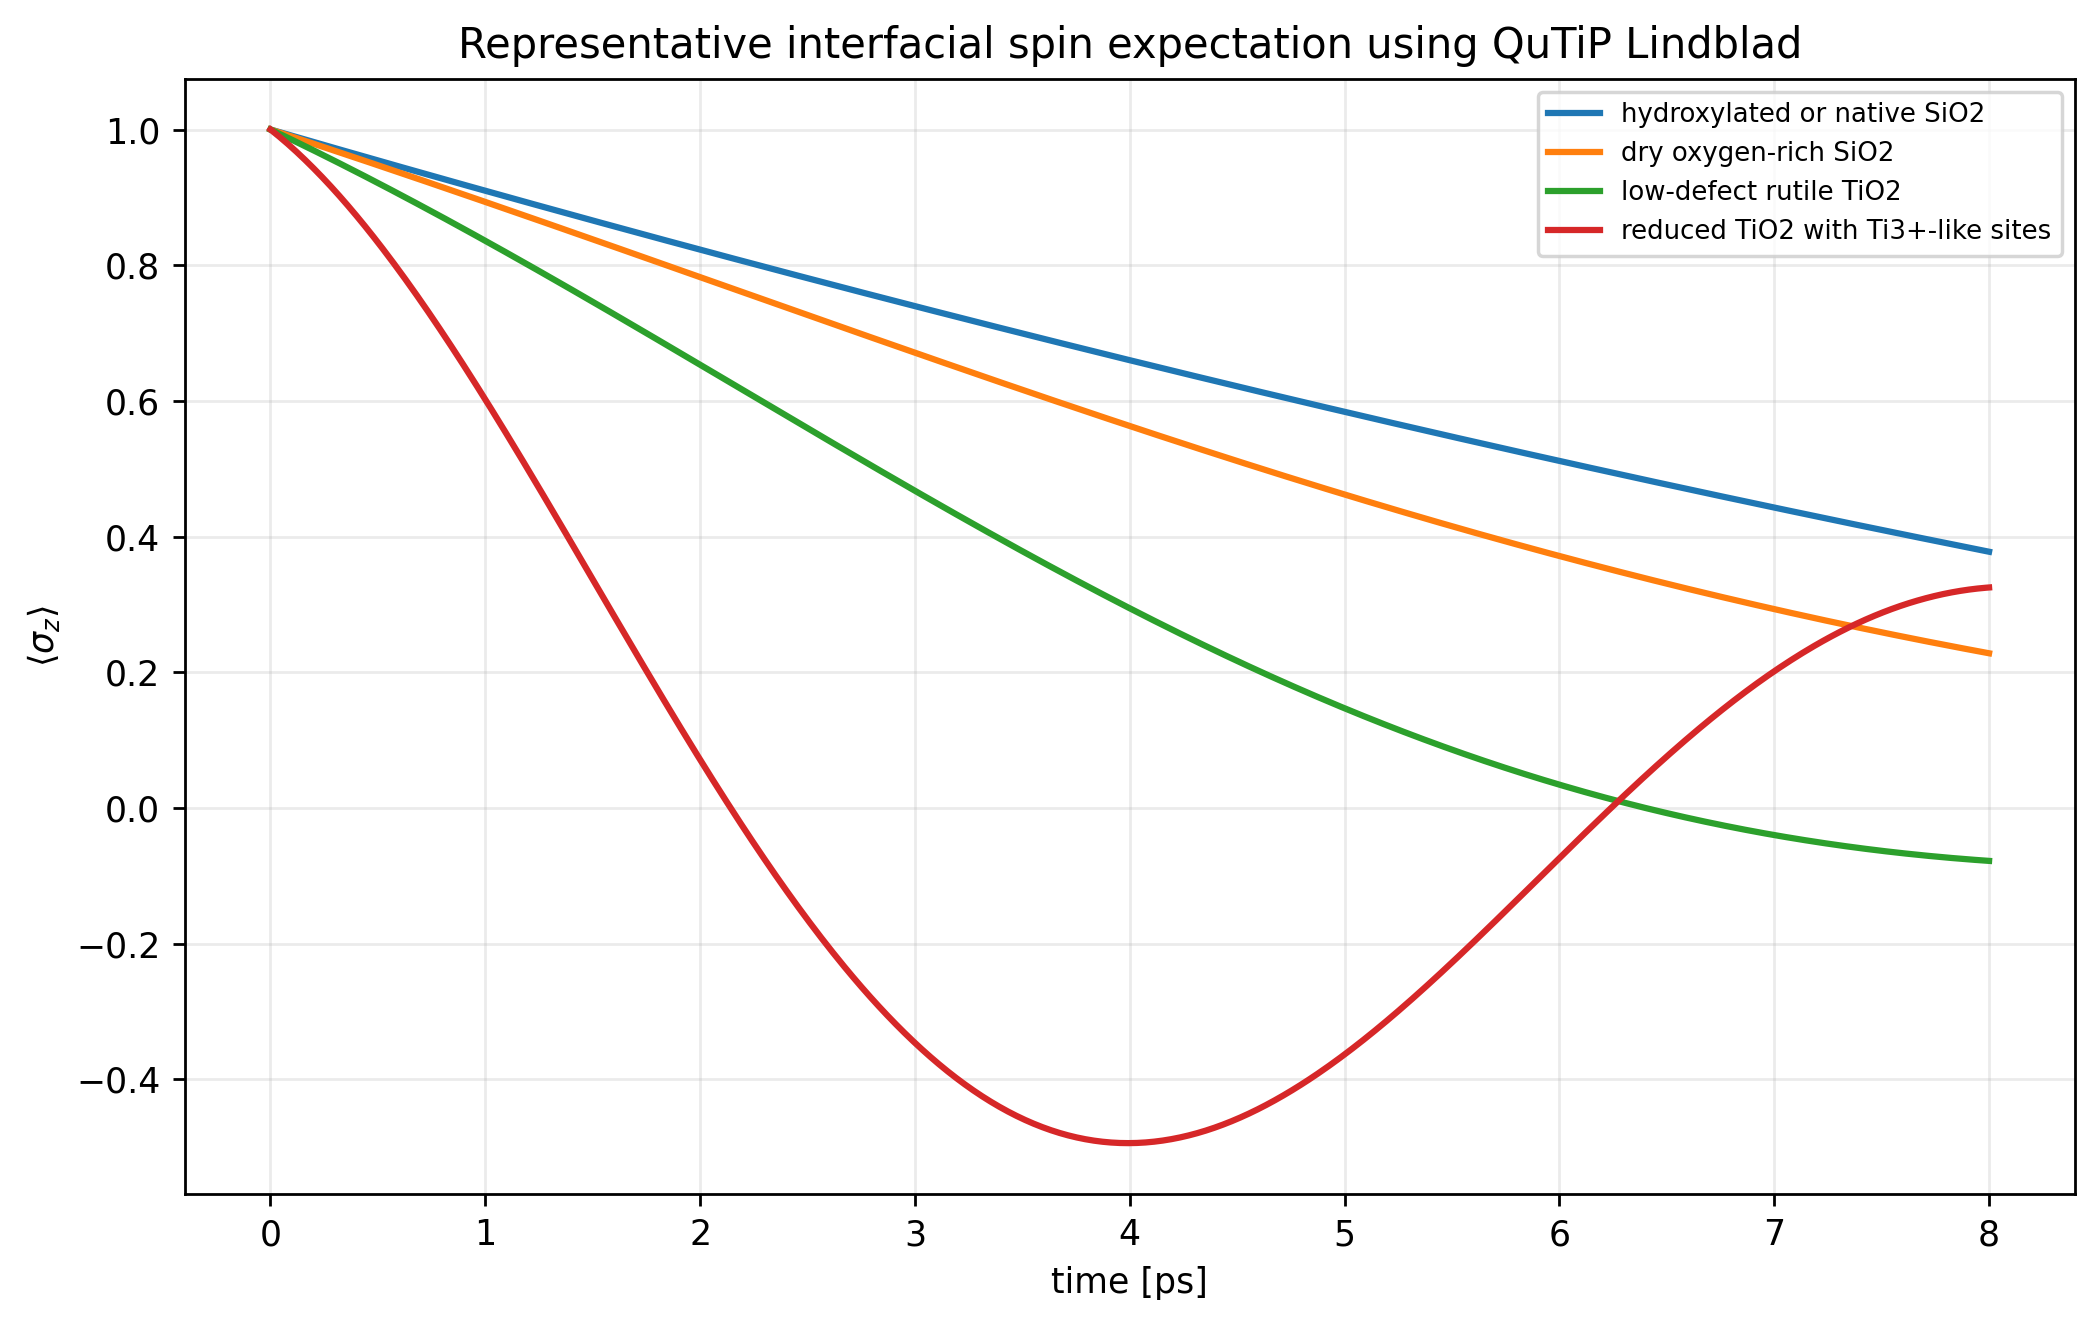

In [ ]:
"""Quantum-informed Cu adhesion descriptor for oxide interfaces.

This notebook cell computes a reduced adhesion proxy for Cu on oxide
interfaces, renders a heat map, prints representative material cases, and
simulates a representative interfacial spin expectation trace. CuPy is used
when a CUDA GPU is available. QuTiP is used when available for the open-system
spin trace, with a SciPy Bloch-equation fallback.
"""

from __future__ import annotations

from dataclasses import dataclass
from typing import Any

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp

# -----------------------------------------------------------------------------
# Control knobs
# -----------------------------------------------------------------------------

MPL_DPI = 250
FIGURE_SIZE = (8.5, 5.4)
HEATMAP_POINTS = 420
TIME_POINTS = 600
TIME_END_PS = 8.0

# Two-level interfacial electronic-structure parameters.
DELTA_0_EV = 2.20
DELTA_MIN_EV = 0.18
DEFECT_ALIGNMENT_GAIN_EV = 1.65
CHARGE_TRANSFER_GAIN_DEFECT = 2.20
CHARGE_TRANSFER_GAIN_HOPPING = 1.10
CHARGE_TRANSFER_THRESHOLD = 0.95
CHARGE_TRANSFER_WIDTH = 0.16

# Adhesion proxy weights and conversion.
SITE_DENSITY_M2 = 5.0e18
EV_TO_J = 1.602176634e-19
HYBRIDIZATION_WEIGHT = 1.00
CHARGE_TRANSFER_WEIGHT = 0.42
DEFECT_BINDING_WEIGHT = 0.35
CHARGE_STABILIZATION_EV = 0.75
DEFECT_STABILIZATION_EV = 0.55
DEFECT_SATURATION = 0.22

# Spin dynamics knobs for the representative trace.
OMEGA_HYB_PSPER_EV = 1.00
OMEGA_DEFECT_PSPER_FRACTION = 0.55
OMEGA_Z_PSPER = 0.35
GAMMA_BASE_PSPER = 0.045
GAMMA_DEFECT_PSPER = 0.080
SIGMA_EQ_Z = 0.20

mpl.rcParams["figure.dpi"] = MPL_DPI
mpl.rcParams["font.family"] = "DejaVu Sans"


@dataclass(frozen=True)
class InterfaceCase:
    """Container for a representative oxide-interface point."""

    name: str
    xi: float
    t_dp_ev: float


INTERFACE_CASES = [
    InterfaceCase("hydroxylated or native SiO2", xi=0.015, t_dp_ev=0.20),
    InterfaceCase("dry oxygen-rich SiO2", xi=0.035, t_dp_ev=0.45),
    InterfaceCase("low-defect rutile TiO2", xi=0.120, t_dp_ev=0.55),
    InterfaceCase("reduced TiO2 with Ti3+-like sites", xi=0.520, t_dp_ev=0.76),
]


def get_array_backend() -> tuple[Any, bool]:
    """Return CuPy when a CUDA device is available, otherwise return NumPy."""
    try:
        import cupy as cp  # pylint: disable=import-outside-toplevel

        device_count = cp.cuda.runtime.getDeviceCount()
        if device_count > 0:
            return cp, True
    except Exception as exc:  # noqa: BLE001
        print(f"CuPy fallback activated: {exc}")
    return np, False


XP, USING_CUPY = get_array_backend()

try:
    import qutip as qt  # pylint: disable=import-error

    USING_QUTIP = True
except Exception as exc:  # noqa: BLE001
    qt = None
    USING_QUTIP = False
    print(f"QuTiP fallback activated: {exc}")


def to_numpy(array: Any) -> np.ndarray:
    """Convert a NumPy or CuPy array to a NumPy array."""
    if USING_CUPY:
        return XP.asnumpy(array)
    return np.asarray(array)


def logistic(array: Any) -> Any:
    """Compute a numerically simple logistic activation."""
    return 1.0 / (1.0 + XP.exp(-array))


def delta_eff_ev(xi: Any) -> Any:
    """Compute the defect-shifted Cu/oxide interfacial level mismatch."""
    return XP.maximum(DELTA_MIN_EV, DELTA_0_EV - DEFECT_ALIGNMENT_GAIN_EV * xi)


def hybridization_energy_ev(xi: Any, t_dp_ev: Any) -> Any:
    """Return the bonding stabilization from a two-level Hamiltonian."""
    delta_ev = delta_eff_ev(xi)
    return XP.sqrt((0.5 * delta_ev) ** 2 + t_dp_ev**2) - 0.5 * delta_ev


def charge_transfer_descriptor(xi: Any, t_dp_ev: Any) -> Any:
    """Return a bounded charge-transfer proxy between zero and one."""
    activation = (
        CHARGE_TRANSFER_GAIN_DEFECT * xi
        + CHARGE_TRANSFER_GAIN_HOPPING * t_dp_ev
        - CHARGE_TRANSFER_THRESHOLD
    ) / CHARGE_TRANSFER_WIDTH
    return logistic(activation)


def adhesion_proxy_mj_m2(xi: Any, t_dp_ev: Any) -> Any:
    """Compute a quantum-informed adhesion proxy in mJ m^-2."""
    e_hyb = hybridization_energy_ev(xi, t_dp_ev)
    q_ct = charge_transfer_descriptor(xi, t_dp_ev)
    e_defect = DEFECT_STABILIZATION_EV * xi / (xi + DEFECT_SATURATION)
    e_site_ev = (
        HYBRIDIZATION_WEIGHT * e_hyb
        + CHARGE_TRANSFER_WEIGHT * CHARGE_STABILIZATION_EV * q_ct
        + DEFECT_BINDING_WEIGHT * e_defect
    )
    return 1.0e3 * SITE_DENSITY_M2 * EV_TO_J * e_site_ev


def case_metrics(case: InterfaceCase) -> dict[str, float | str]:
    """Build a dictionary of scalar metrics for one representative interface."""
    xi = XP.asarray(case.xi, dtype=XP.float64)
    t_dp = XP.asarray(case.t_dp_ev, dtype=XP.float64)
    e_hyb = float(to_numpy(hybridization_energy_ev(xi, t_dp)))
    q_ct = float(to_numpy(charge_transfer_descriptor(xi, t_dp)))
    adhesion = float(to_numpy(adhesion_proxy_mj_m2(xi, t_dp)))
    delta = float(to_numpy(delta_eff_ev(xi)))
    omega_x = OMEGA_HYB_PSPER_EV * e_hyb + OMEGA_DEFECT_PSPER_FRACTION * case.xi
    gamma = GAMMA_BASE_PSPER + GAMMA_DEFECT_PSPER * q_ct
    return {
        "case": case.name,
        "xi": case.xi,
        "t_dp_eV": case.t_dp_ev,
        "delta_eff_eV": delta,
        "E_hyb_eV_per_site": e_hyb,
        "q_ct": q_ct,
        "W_ad_proxy_mJ_m2": adhesion,
        "Omega_x_ps^-1": omega_x,
        "Gamma_ps^-1": gamma,
    }


def simulate_spin_with_qutip(case: InterfaceCase) -> tuple[np.ndarray, np.ndarray]:
    """Simulate <sigma_z> using QuTiP Lindblad dynamics."""
    metrics = case_metrics(case)
    time_ps = np.linspace(0.0, TIME_END_PS, TIME_POINTS)
    omega_x = float(metrics["Omega_x_ps^-1"])
    gamma = float(metrics["Gamma_ps^-1"])
    omega_z = OMEGA_Z_PSPER

    sx = qt.sigmax()
    sz = qt.sigmaz()
    sm = qt.sigmam()
    hamiltonian = 0.5 * omega_x * sx + 0.5 * omega_z * sz
    initial_state = qt.basis(2, 0)
    collapse_ops = [np.sqrt(max(gamma, 0.0)) * sm]
    result = qt.mesolve(
        hamiltonian,
        initial_state,
        time_ps,
        c_ops=collapse_ops,
        e_ops=[sz],
        options={"progress_bar": ""},
    )
    return time_ps, np.asarray(result.expect[0], dtype=float)


def bloch_rhs(_: float, spin: np.ndarray, omega: np.ndarray, gamma: float) -> np.ndarray:
    """Return the damped Ehrenfest/Bloch right-hand side."""
    spin_eq = np.array([0.0, 0.0, SIGMA_EQ_Z], dtype=float)
    return np.cross(omega, spin) - gamma * (spin - spin_eq)


def simulate_spin_with_scipy(case: InterfaceCase) -> tuple[np.ndarray, np.ndarray]:
    """Simulate <sigma_z> with a damped Bloch-equation fallback."""
    metrics = case_metrics(case)
    time_ps = np.linspace(0.0, TIME_END_PS, TIME_POINTS)
    omega = np.array(
        [float(metrics["Omega_x_ps^-1"]), 0.0, OMEGA_Z_PSPER],
        dtype=float,
    )
    gamma = float(metrics["Gamma_ps^-1"])
    initial_spin = np.array([0.0, 0.0, 1.0], dtype=float)
    solution = solve_ivp(
        bloch_rhs,
        t_span=(time_ps[0], time_ps[-1]),
        y0=initial_spin,
        t_eval=time_ps,
        args=(omega, gamma),
        rtol=1.0e-8,
        atol=1.0e-10,
    )
    return time_ps, solution.y[2]


def simulate_spin(case: InterfaceCase) -> tuple[np.ndarray, np.ndarray]:
    """Run the preferred spin solver for one interface case."""
    if USING_QUTIP:
        return simulate_spin_with_qutip(case)
    return simulate_spin_with_scipy(case)


def plot_heatmap() -> None:
    """Render an adhesion heat map over defect density and hopping amplitude."""
    xi_grid = XP.linspace(0.0, 0.80, HEATMAP_POINTS, dtype=XP.float64)
    t_grid = XP.linspace(0.05, 1.05, HEATMAP_POINTS, dtype=XP.float64)
    t_mesh, xi_mesh = XP.meshgrid(t_grid, xi_grid)
    adhesion = to_numpy(adhesion_proxy_mj_m2(xi_mesh, t_mesh))

    fig, ax = plt.subplots(figsize=FIGURE_SIZE)
    image = ax.imshow(
        adhesion,
        origin="lower",
        aspect="auto",
        extent=[
            float(to_numpy(t_grid[0])),
            float(to_numpy(t_grid[-1])),
            float(to_numpy(xi_grid[0])),
            float(to_numpy(xi_grid[-1])),
        ],
    )
    cbar = fig.colorbar(image, ax=ax)
    cbar.set_label(r"Adhesion proxy $W_{ad}$ [mJ m$^{-2}$]")

    for case in INTERFACE_CASES:
        ax.plot(case.t_dp_ev, case.xi, marker="o", linestyle="None", label=case.name)
        ax.annotate(
            case.name,
            xy=(case.t_dp_ev, case.xi),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=7.5,
        )

    ax.set_title("Quantum-informed Cu/oxide adhesion heat map")
    ax.set_xlabel(r"Cu-oxide hopping amplitude $|t_{dp}|$ [eV]")
    ax.set_ylabel(r"Defect-mediated electron-rich site fraction $\xi$")
    ax.legend(loc="upper left", fontsize=7.3, frameon=True)
    fig.tight_layout()
    plt.show()


def plot_spin_traces() -> None:
    """Render representative interfacial spin expectation traces."""
    fig, ax = plt.subplots(figsize=FIGURE_SIZE)
    for case in INTERFACE_CASES:
        time_ps, sigma_z = simulate_spin(case)
        ax.plot(time_ps, sigma_z, label=case.name, linewidth=1.8)

    solver_name = "QuTiP Lindblad" if USING_QUTIP else "SciPy damped Bloch"
    ax.set_title(f"Representative interfacial spin expectation using {solver_name}")
    ax.set_xlabel("time [ps]")
    ax.set_ylabel(r"$\langle \sigma_z \rangle$")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best", fontsize=7.5)
    fig.tight_layout()
    plt.show()


def main() -> pd.DataFrame:
    """Compute, print, and plot the reduced Cu/oxide adhesion model."""
    print(f"Array backend: {'CuPy CUDA' if USING_CUPY else 'NumPy CPU'}")
    print(f"Spin solver: {'QuTiP Lindblad' if USING_QUTIP else 'SciPy damped Bloch'}")

    metrics = pd.DataFrame(case_metrics(case) for case in INTERFACE_CASES)
    numeric_columns = metrics.select_dtypes(include=["number"]).columns
    metrics[numeric_columns] = metrics[numeric_columns].round(5)
    print("\nRepresentative interface metrics:")
    print(metrics.to_string(index=False))

    plot_heatmap()
    plot_spin_traces()
    return metrics


if __name__ == "__main__":
    results = main()

### How to read the results

The heat map should show a monotonic rise in the adhesion proxy when the Cu-oxide hopping amplitude grows and when the interface contains a larger fraction of reducible electron-rich sites. The reduced-TiO2 point should fall in a high-adhesion region because both the defect-mediated alignment term and the hopping term are active. Hydroxylated or native SiO2 should fall lower because its effective hopping and reducible-site density are both small. Dry oxygen-rich SiO2 can move upward in the map because Cu-O hybridization becomes more favorable even when $\xi$ remains small.

The spin traces are illustrative. They show how the same interfacial parameters can be mapped into a spin-sensitive effective field and a relaxation channel. A stronger hybridization and charge-transfer environment increases the precession and damping scales, which is the reduced-model signature expected near a more electronically active interface.

### References

Nagao, Neaton, and Ashcroft, *First-principles study of adhesion at Cu/SiO2 interfaces*, arXiv:cond-mat/0304459 and Physical Review B 68, 125403. The abstract reports that adhesion depends on surface oxygen density, oxygen-rich interfaces form Cu-O bonds with Cu-$d$/O-$p$ hybridization, oxygen removal weakens adhesion, and hydroxyl termination reduces adhesion.

Janulaitis, Zhao, and Campbell, *Energetics of Cu adsorption on and adhesion to rutile-TiO2(100) studied by Cu vapor adsorption calorimetry*, Journal of Physical Chemistry C, 2024. The preprint reports measured heats of Cu adsorption on rutile TiO2 and discusses defect-density effects in the initial adsorption regime.

Grebien and Al-Shamery, *Charge transfer at interfaces of copper clusters on TiO2(110) and SiOx*, Surface Science, 2024. The paper reports XPS and Auger-parameter evidence for support-dependent charge-transfer signatures in Cu clusters on rutile TiO2 and native SiOx.

Zhang et al., *Oxygen vacancies in Cu/TiO2 boost strong metal-support interaction and CO2 hydrogenation to methanol*, Journal of Catalysis, 2022. The paper reports that oxygen vacancies in reduced TiO2 induce strong metal-support interaction and improve Cu dispersion and stability.

Atxitia, Hinzke, and Nowak, *Fundamentals and applications of the Landau-Lifshitz-Bloch equation*, Journal of Physics D, 2017. The review explains finite-temperature magnetization dynamics through the Landau-Lifshitz-Bloch framework.

QuTiP 5.3 documentation describes density-matrix evolution under Hamiltonians and collapse operators through `mesolve`. CuPy documentation describes CuPy as a NumPy/SciPy-compatible GPU array library.